<a href="https://colab.research.google.com/github/laykhaaa-818/data-engine-pipeline-miniproject/blob/main/data_engineer_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐾 Principle of AI: Mini Project
## Role: Data Engineer | Domain: Animal Subspecies

---

**Tasks covered in this notebook:**
- ✅ Phase 1: Collecting data (web crawling ~10,000 images)
- ✅ Phase 2: Standardising data (resize, RGB, deduplication)
- ✅ Phase 3: Creating dataset (train/val/test split + CSV export)

**Dataset classes (5 animal groups, 18 subspecies labels):**

| Class | Subspecies labels |
|---|---|
| Tiger | Bengal, Siberian, Sumatran, Indochinese |
| Lion | African, Asiatic, White |
| Leopard | African, Amur, Snow, Clouded |
| Wolf | Grey, Arctic, Ethiopian |
| Eagle | Bald, Golden, Harpy, Steppe |

**Split ratio:** 70% train · 15% val · 15% test

---



---
## ⚙️ Cell 1 — Install dependencies

In [1]:
# Install all required libraries
!pip install bing-image-downloader Pillow imagehash split-folders pandas tqdm --quiet
print("✅ All dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 3.5 MB/s eta 0:00:00
✅ All dependencies installed.


---
## 💾 Cell 2 — Mount Google Drive
> Your dataset will be saved to `MyDrive/animal_dataset/`. This keeps your files safe if the Colab session times out.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted.")

Mounted at /content/drive
✅ Google Drive mounted.


---
## 🔧 Cell 3 — Configuration & imports

In [3]:
import os
import pathlib
import shutil
import logging
import pandas as pd
import imagehash
import splitfolders

from PIL import Image, UnidentifiedImageError
from tqdm.notebook import tqdm
from bing_image_downloader import downloader

# ── Paths (all saved to Google Drive) ─────────────────────────
BASE        = pathlib.Path("/content/drive/MyDrive/animal_dataset")
RAW_DIR     = BASE / "raw_data"
CLEAN_DIR   = BASE / "clean_data"
DATASET_DIR = BASE / "dataset"
CSV_OUT     = BASE / "dataset.csv"
LOG_FILE    = BASE / "pipeline.log"

BASE.mkdir(parents=True, exist_ok=True)

# ── Image settings ─────────────────────────────────────────────
TARGET_SIZE  = (224, 224)          # Standard for transfer learning
SPLIT_RATIO  = (0.70, 0.15, 0.15)  # train / val / test
RANDOM_SEED  = 42

# ── Crawl queries ──────────────────────────────────────────────
# Format: ("search query", "folder_label", number_of_images)
# 18 subspecies × ~555 images ≈ 10,000 total
QUERIES = [
    # Tiger
    ("Bengal tiger wildlife",        "tiger_bengal",       500),
    ("Siberian tiger wildlife",      "tiger_siberian",     500),
    ("Sumatran tiger wildlife",      "tiger_sumatran",     500),
    ("Indochinese tiger wildlife",   "tiger_indochinese",  500),
    # Lion
    ("African lion wildlife",        "lion_african",       500),
    ("Asiatic lion wildlife",        "lion_asiatic",       500),
    ("White lion wildlife",          "lion_white",         500),
    # Leopard
    ("African leopard wildlife",     "leopard_african",    500),
    ("Amur leopard wildlife",        "leopard_amur",       500),
    ("Snow leopard wildlife",        "leopard_snow",       500),
    ("Clouded leopard wildlife",     "leopard_clouded",    500),
    # Wolf
    ("Grey wolf wildlife",           "wolf_grey",          500),
    ("Arctic wolf wildlife",         "wolf_arctic",        500),
    ("Ethiopian wolf wildlife",      "wolf_ethiopian",     500),
    # Eagle
    ("Bald eagle wildlife",          "eagle_bald",         250),
    ("Golden eagle wildlife",        "eagle_golden",       250),
    ("Harpy eagle wildlife",         "eagle_harpy",        250),
    ("Steppe eagle wildlife",        "eagle_steppe",       250),
]

# ── Logging ─────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE, encoding="utf-8"),
        logging.StreamHandler()
    ]
)
log = logging.getLogger(__name__)

print("✅ Configuration loaded.")
print(f"   Base directory : {BASE}")
print(f"   Total queries  : {len(QUERIES)}")
print(f"   Target images  : ~{sum(q[2] for q in QUERIES):,}")

✅ Configuration loaded.
   Base directory : /content/drive/MyDrive/animal_dataset
   Total queries  : 18
   Target images  : ~8,000


---
## 📥 Cell 4 — Phase 1: Collect images
> Crawls Bing Images for every subspecies query and saves to `raw_data/`.
> Already-downloaded folders are skipped automatically — safe to re-run.

In [4]:
log.info("=" * 60)
log.info("PHASE 1 — COLLECTING IMAGES")
log.info("=" * 60)

for query, folder, limit in QUERIES:
    out_path = RAW_DIR / folder
    existing = len(list(out_path.glob("*"))) if out_path.exists() else 0

    if existing >= limit * 0.8:
        log.info(f"[SKIP]  '{folder}' already has {existing} images — skipping.")
        continue

    log.info(f"[CRAWL] '{query}'  →  {folder}  (limit={limit})")
    try:
        downloader.download(
            query,
            limit=limit,
            output_dir=str(RAW_DIR),
            adult_filter_off=False,
            force_replace=False,
            timeout=60,
            verbose=False
        )
        # Rename folder from query string to our clean label
        query_folder = RAW_DIR / query
        if query_folder.exists() and not out_path.exists():
            query_folder.rename(out_path)
    except Exception as e:
        log.warning(f"[WARN]  Crawl failed for '{query}': {e}")

total_raw = sum(1 for _ in RAW_DIR.rglob("*") if _.is_file())
print(f"\n✅ Phase 1 done — {total_raw:,} raw images collected.")

[%] Downloading Images to /content/drive/MyDrive/animal_dataset/raw_data/Bengal tiger wildlife
[!] Issue getting: https://64.media.tumblr.com/d3eedb6a868c9b4b3ba837ae6d9d1f46/4411d024feab2d77-69/s128x128u_c1/0659812eb6b3c7ae6a71df07b40bfdfb1775407e.pnj
[!] Error:: Invalid image, not saving https://64.media.tumblr.com/d3eedb6a868c9b4b3ba837ae6d9d1f46/4411d024feab2d77-69/s128x128u_c1/0659812eb6b3c7ae6a71df07b40bfdfb1775407e.pnj
[!] Issue getting: https://64.media.tumblr.com/60e81c930e971a402d3a0fc51e318529/91b282a3a6d095a1-64/s128x128u_c1/24e907cb0e4ede3abfa5d9ed1af6178c810b5540.jpg
[!] Error:: Invalid image, not saving https://64.media.tumblr.com/60e81c930e971a402d3a0fc51e318529/91b282a3a6d095a1-64/s128x128u_c1/24e907cb0e4ede3abfa5d9ed1af6178c810b5540.jpg
[!] Issue getting: https://www.researchgate.net/profile/Tulika-Basu/publication/311669620/figure/fig2/AS:11431281090185104@1665985469479/overall-place-of-retroflection-and-release-for-t-t-h-and-d-It-can-be-observed-from_Q320.jpg
[!] Er

---
## 🔄 Cell 5 — Phase 2a: Resize & convert to RGB
> Converts every image to 224×224 RGB JPEG. Corrupt files are skipped and logged.

In [5]:
log.info("=" * 60)
log.info("PHASE 2a — RESIZE & CONVERT")
log.info("=" * 60)

saved = 0
skipped = 0

all_raw = [p for p in RAW_DIR.rglob("*") if p.is_file()]
print(f"Processing {len(all_raw):,} raw files ...")

for img_path in tqdm(all_raw, desc="Resizing"):
    class_name = img_path.parent.name
    out_dir    = CLEAN_DIR / class_name
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path   = out_dir / (img_path.stem + ".jpg")

    if out_path.exists():
        continue

    try:
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            img = img.resize(TARGET_SIZE, Image.LANCZOS)
            img.save(out_path, "JPEG", quality=90)
        saved += 1
    except Exception:
        skipped += 1

print(f"\n✅ Resize done — Saved: {saved:,}  |  Corrupt/skipped: {skipped}")

Processing 595 raw files ...


Resizing:   0%|          | 0/595 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



✅ Resize done — Saved: 595  |  Corrupt/skipped: 0


---
## 🔍 Cell 6 — Phase 2b: Deduplicate with perceptual hashing
> Uses pHash to detect and remove near-duplicate images across the entire dataset.

In [6]:
log.info("PHASE 2b — DEDUPLICATION")

seen_hashes = {}
duplicates_removed = 0

all_clean = list(CLEAN_DIR.rglob("*.jpg"))
print(f"Checking {len(all_clean):,} images for duplicates ...")

for img_path in tqdm(all_clean, desc="Deduplicating"):
    try:
        with Image.open(img_path) as img:
            h = imagehash.phash(img)
    except Exception:
        img_path.unlink(missing_ok=True)
        continue

    if h in seen_hashes:
        img_path.unlink(missing_ok=True)
        duplicates_removed += 1
    else:
        seen_hashes[h] = img_path

total_clean = sum(1 for _ in CLEAN_DIR.rglob("*.jpg"))
print(f"\n✅ Dedup done — Removed: {duplicates_removed} duplicates")
print(f"   Clean images remaining: {total_clean:,}")

Checking 595 images for duplicates ...


Deduplicating:   0%|          | 0/595 [00:00<?, ?it/s]


✅ Dedup done — Removed: 6 duplicates
   Clean images remaining: 589


---
## 📂 Cell 7 — Phase 3a: Train / Val / Test split
> Splits `clean_data/` into `dataset/train`, `dataset/val`, `dataset/test` using a 70/15/15 ratio.

In [7]:
log.info("=" * 60)
log.info("PHASE 3a — TRAIN / VAL / TEST SPLIT")
log.info("=" * 60)

if DATASET_DIR.exists():
    print("[INFO] dataset/ already exists — removing and re-splitting.")
    shutil.rmtree(DATASET_DIR)

print(f"Splitting with ratio: train={SPLIT_RATIO[0]} | val={SPLIT_RATIO[1]} | test={SPLIT_RATIO[2]}")

splitfolders.ratio(
    str(CLEAN_DIR),
    output=str(DATASET_DIR),
    seed=RANDOM_SEED,
    ratio=SPLIT_RATIO,
    group_prefix=None,
    move=False
)

print("\n✅ Split complete. Folder structure:")
for split in ["train", "val", "test"]:
    count = sum(1 for _ in (DATASET_DIR / split).rglob("*.jpg"))
    print(f"   {split:6s}  →  {count:,} images")

Splitting with ratio: train=0.7 | val=0.15 | test=0.15


Copying files: 589 files [00:10, 57.02 files/s]


✅ Split complete. Folder structure:
   train   →  404 images
   val     →  80 images
   test    →  105 images


---
## 📊 Cell 8 — Phase 3b: Export dataset.csv + summary
> Generates a CSV mapping every image to its class and split. This is the handoff file for the **Data Analyst**.

In [8]:
log.info("PHASE 3b — EXPORT CSV METADATA")

rows = []
for split in ["train", "val", "test"]:
    for img_path in (DATASET_DIR / split).rglob("*.jpg"):
        rows.append({
            "filepath" : str(img_path),
            "class"    : img_path.parent.name,
            "split"    : split
        })

df = pd.DataFrame(rows)
df.to_csv(CSV_OUT, index=False)

print(f"✅ dataset.csv saved → {CSV_OUT}")
print(f"   Total rows: {len(df):,}\n")

# ── Summary table ──────────────────────────────────────────────
summary = df.groupby(["class", "split"]).size().unstack(fill_value=0)
summary["TOTAL"] = summary.sum(axis=1)

print("=" * 65)
print("  DATASET SUMMARY")
print("=" * 65)
print(summary.to_string())
print("-" * 65)
print(f"  Grand total : {len(df):,} images")
print(f"  Classes     : {df['class'].nunique()}")
print(f"  CSV saved   : {CSV_OUT}")
print("=" * 65)

✅ dataset.csv saved → /content/drive/MyDrive/animal_dataset/dataset.csv
   Total rows: 589

  DATASET SUMMARY
split              test  train  val  TOTAL
class                                     
eagle_bald            2      7    1     10
eagle_golden          1      2    0      3
eagle_harpy           3      7    1     11
eagle_steppe          4     12    2     18
leopard_african      11     45    9     65
leopard_amur         29    129   27    185
leopard_clouded       4     15    3     22
leopard_snow          6     23    4     33
lion_african          2      4    0      6
lion_asiatic          2      2    0      4
lion_white            6     23    5     34
tiger_bengal         11     48   10     69
tiger_indochinese     1      0    0      1
tiger_siberian        4     15    3     22
tiger_sumatran        2      4    1      7
wolf_arctic           3     11    2     16
wolf_ethiopian       13     56   12     81
wolf_grey             1      1    0      2
------------------------------

---
## 📋 Cell 9 — Class distribution check (for Data Analyst handoff)
> Shows a bar chart of image counts per class. Flag any class imbalance here for the Data Scientist.

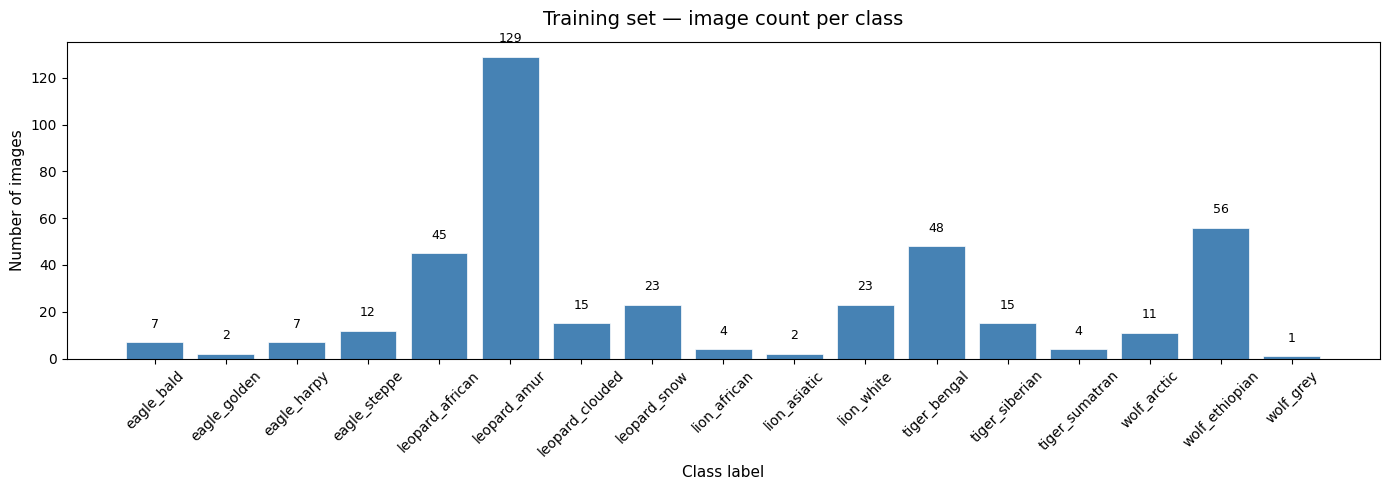

✅ Chart saved → /content/drive/MyDrive/animal_dataset/class_distribution.png


In [9]:
import matplotlib.pyplot as plt

class_counts = df[df["split"] == "train"]["class"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(class_counts.index, class_counts.values, color="steelblue", edgecolor="white", linewidth=0.5)

ax.set_title("Training set — image count per class", fontsize=14, pad=12)
ax.set_xlabel("Class label", fontsize=11)
ax.set_ylabel("Number of images", fontsize=11)
ax.tick_params(axis="x", rotation=45)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(int(bar.get_height())),
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
chart_path = BASE / "class_distribution.png"
plt.savefig(chart_path, dpi=150)
plt.show()
print(f"✅ Chart saved → {chart_path}")

---
## ✅ Cell 10 — Pipeline complete
> Summary of all output files produced.

In [10]:
print("╔══════════════════════════════════════════════════╗")
print("║   DATA ENGINEER PIPELINE — COMPLETE              ║")
print("╚══════════════════════════════════════════════════╝\n")

outputs = [
    ("Raw images",       RAW_DIR),
    ("Clean images",     CLEAN_DIR),
    ("Train/Val/Test",   DATASET_DIR),
    ("Metadata CSV",     CSV_OUT),
    ("Run log",          LOG_FILE),
    ("Class chart",      BASE / "class_distribution.png"),
]

for label, path in outputs:
    exists = "✅" if path.exists() else "❌"
    print(f"  {exists}  {label:18s}  →  {path}")

print("\n📁 Everything saved to Google Drive under: animal_dataset/")
print("📬 Hand dataset.csv to the Data Analyst.")
print("📬 Hand dataset/ folder structure to the Data Scientist.")

╔══════════════════════════════════════════════════╗
║   DATA ENGINEER PIPELINE — COMPLETE              ║
╚══════════════════════════════════════════════════╝

  ✅  Raw images          →  /content/drive/MyDrive/animal_dataset/raw_data
  ✅  Clean images        →  /content/drive/MyDrive/animal_dataset/clean_data
  ✅  Train/Val/Test      →  /content/drive/MyDrive/animal_dataset/dataset
  ✅  Metadata CSV        →  /content/drive/MyDrive/animal_dataset/dataset.csv
  ✅  Run log             →  /content/drive/MyDrive/animal_dataset/pipeline.log
  ✅  Class chart         →  /content/drive/MyDrive/animal_dataset/class_distribution.png

📁 Everything saved to Google Drive under: animal_dataset/
📬 Hand dataset.csv to the Data Analyst.
📬 Hand dataset/ folder structure to the Data Scientist.
